# Udemy Courses Analysis

## 1] Analysis

### importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import re

### load dataset

In [2]:
df = pd.read_csv("udemy_courses.csv")

#### show sample of Dataset

In [3]:
df.sample(5)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
1322,742392,Conviértete en un experto de photoshop cc nake...,https://www.udemy.com/photoshop-cc-naked-series/,True,30,24,5,122,Intermediate Level,12 hours,2016-01-29T02:54:19Z,Graphic Design
944,115752,Straight From Business School: Create Financia...,https://www.udemy.com/straight-from-business-s...,True,20,31,2,5,Beginner Level,1 hour,2013-11-28T01:07:56Z,Business Finance
3333,708578,Bootstrap 4 Quick Start: Code Modern Responsiv...,https://www.udemy.com/bootstrap-4/,False,Free,41478,2104,13,All Levels,3 hours,2015-12-30T21:28:31Z,Web Development
1966,347104,Learn to Play the Oboe: Beginner to Pro in Und...,https://www.udemy.com/oboe-a-beginners-guide/,TRUE,50,500,39,74,Beginner Level,5 hours,2015-01-01T01:25:25Z,Musical Instruments
3547,611688,PSD to Bootstrap 3 for Beginners using HTML & CSS,https://www.udemy.com/psd-to-bootstrap/,True,20,976,93,46,Beginner Level,2.5 hours,2015-11-03T21:03:34Z,Web Development


#### information about dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3683 non-null   int64 
 1   course_title         3683 non-null   object
 2   url                  3683 non-null   object
 3   is_paid              3683 non-null   object
 4   price                3683 non-null   object
 5   num_subscribers      3683 non-null   int64 
 6   num_reviews          3683 non-null   int64 
 7   num_lectures         3683 non-null   int64 
 8   level                3683 non-null   object
 9   content_duration     3683 non-null   object
 10  published_timestamp  3683 non-null   object
 11  subject              3683 non-null   object
dtypes: int64(4), object(8)
memory usage: 345.4+ KB


#### there are 4 columns numirical like course_id , num_subscribers , num_reviews , num_lectures 
#### there are 8 columns object like course_title , url , is_paid , price , level ,content_duration,published_timestamp,subject              

#### discraib dataset

In [5]:
df.describe()

,course_id,num_subscribers,num_reviews,num_lectures
count,3.683000e+03,3683.000000,3683.000000,3683.000000
mean,6.764546e+05,3193.371165,156.448004,40.062178
std,3.437217e+05,9498.231406,935.078241,50.366788
min,8.324000e+03,0.000000,0.000000,0.000000
25%,4.077270e+05,110.000000,4.000000,15.000000
50%,6.882440e+05,911.000000,18.000000,25.000000
75%,9.617290e+05,2537.500000,67.000000,45.000000
max,1.282064e+06,268923.000000,27445.000000,779.000000


### Data Preprocessing

#### why price is object ??

In [6]:
df['price'].value_counts()

price
20      830
50      468
Free    310
200     295
40      217
30      170
25      154
95      152
100     133
195     127
35      116
150      88
45       83
75       81
60       75
120      37
55       35
85       31
125      30
65       30
80       29
145      27
70       26
90       19
180      17
115      16
175      13
105      11
190      10
140      10
135       8
110       8
185       6
165       6
170       5
160       4
130       3
155       2
TRUE      1
Name: count, dtype: int64

### becouse the free course write "free" Not 0

In [7]:
df[df['price']=="Free"]


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
97,1148774,Options Trading 101: The Basics,https://www.udemy.com/options-trading-101-the-...,False,Free,1514,66,11,Beginner Level,33 mins,2017-03-23T22:19:57Z,Business Finance
105,133536,Stock Market Investing for Beginners,https://www.udemy.com/the-beginners-guide-to-t...,False,Free,50855,2698,15,Beginner Level,1.5 hours,2013-12-25T19:53:34Z,Business Finance
108,265960,Fundamentals of Forex Trading,https://www.udemy.com/fundamentals-of-forex-tr...,False,Free,17160,620,23,All Levels,1 hour,2014-08-29T20:10:38Z,Business Finance
110,923616,Website Investing 101 - Buying & Selling Onlin...,https://www.udemy.com/cash-flow-website-invest...,False,Free,6811,151,51,All Levels,2 hours,2016-08-05T17:03:15Z,Business Finance
114,191854,Stock Market Foundations,https://www.udemy.com/how-to-invest-in-the-sto...,False,Free,19339,794,9,Beginner Level,2 hours,2014-03-31T21:35:06Z,Business Finance
...,...,...,...,...,...,...,...,...,...,...,...,...
3643,155640,Building a Search Engine in PHP & MySQL,https://www.udemy.com/creating-a-search-engine...,False,Free,10110,379,12,All Levels,2.5 hours,2014-02-03T18:07:52Z,Web Development
3648,366720,CSS Image filters - The modern web images colo...,https://www.udemy.com/super-awesome-images-wit...,False,Free,6315,53,16,All Levels,1.5 hours,2014-12-10T19:43:40Z,Web Development
3656,1079078,Drupal 8 Site Building,https://www.udemy.com/drupal-8-site-building/,False,Free,1942,23,48,All Levels,4.5 hours,2017-05-02T05:15:52Z,Web Development
3670,21386,Beginner Photoshop to HTML5 and CSS3,https://www.udemy.com/psd-html5-css3/,False,Free,73110,1716,22,All Levels,2 hours,2012-07-27T12:54:57Z,Web Development


### and one of this course price write "TRUE"

In [8]:
df[df['price']=="TRUE"]


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
2066,96698,Learn Classical Guitar Technique and play 'Spa...,"000!""",https://www.udemy.com/learnguitartoworship/,TRUE,30,1463,29,52,Beginner Level,3 hours,Musical Instruments


#### how to solve this issue

##### i will make replace free with 0

In [9]:
df['price']=df['price'].replace("Free",0)

##### i will drop one row when price "True"

In [10]:
df=df.drop(df[df['price']=="TRUE"].index)

#### to confirmed the price issue solved

In [11]:
df['price']=pd.to_numeric(df['price'])
df['price'].dtype

dtype('int64')

#### why is_paid is object ??

In [12]:
df['is_paid'].value_counts()

is_paid
True     2738
TRUE      634
False     264
FALSE      46
Name: count, dtype: int64

##### There are two very serious errors in "is_paid" column.
###### First, a naming error: there are two different names for "true" and there are two different names for "false".
###### Second, we convert it to 0 and 1.

In [13]:
df['is_paid']=df['is_paid'].replace("TRUE","True")
df['is_paid']=df['is_paid'].replace("FALSE","False")

In [14]:
# to confirm the first error is solved
df['is_paid'].value_counts()

is_paid
True     3372
False     310
Name: count, dtype: int64

In [15]:
df['is_paid']=df['is_paid'].map({'True':1,'False':0})


In [16]:
df['is_paid']=pd.to_numeric(df['is_paid'])

In [17]:
# to confirm the second error is solved
df['is_paid'].value_counts()

is_paid
1    3372
0     310
Name: count, dtype: int64

#### why column level is object??

In [18]:
df['level'].value_counts()

level
All Levels            1932
Beginner Level        1271
Intermediate Level     421
Expert Level            58
Name: count, dtype: int64

#### why column published_timestamp is object??

In [19]:
df['published_timestamp'].dtype

dtype('O')

#### convert the column to date

In [20]:
df['published_timestamp']=pd.to_datetime(df['published_timestamp'])

#### split this column to year and month and day and quarter and period

In [21]:
df['year']=df['published_timestamp'].dt.year
df['month']=df['published_timestamp'].dt.month_name()
df['day']=df['published_timestamp'].dt.day_name()
df['quarter']=df['published_timestamp'].dt.quarter
df['period'] = df['published_timestamp'].dt.strftime('%p')

#### make published_timestamp column as index

In [22]:
df.set_index('published_timestamp',inplace=True)

In [23]:
df.sample(5)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,year,month,day,quarter,period
published_timestamp,,,,,,,,,,,,,,,,
2015-07-14 20:30:11+00:00,552594,Create Complete Web Applications easily with A...,https://www.udemy.com/create-web-apps-with-ape...,1,30,912,128,81,Intermediate Level,7 hours,Web Development,2015,July,Tuesday,3,PM
2017-02-14 03:09:24+00:00,1103526,Pure Modal Magic: The Complete Guitar Modes So...,https://www.udemy.com/pure-modal-magic/,1,50,52,3,18,All Levels,2 hours,Musical Instruments,2017,February,Tuesday,1,AM
2015-07-26 17:44:17+00:00,563248,JavaScript Step by Step how to apply it to you...,https://www.udemy.com/javascript-fundamentals-...,1,100,13406,78,44,All Levels,1.5 hours,Web Development,2015,July,Sunday,3,PM
2017-05-30 00:19:02+00:00,1224186,Learn to Play Piano Like a Pro - Easy Piano Co...,https://www.udemy.com/learn-to-play-piano-like...,1,35,0,0,13,Beginner Level,31 mins,Musical Instruments,2017,May,Tuesday,2,AM
2017-06-20 19:53:50+00:00,1244302,Guitar Strumming 101 - Have More Fun Playing S...,https://www.udemy.com/guitar-strumming-101-hav...,1,50,8,2,16,Beginner Level,1 hour,Musical Instruments,2017,June,Tuesday,2,PM


#### add new column profit

In [24]:
df['profit']=df['price']*df['num_subscribers']

#### cheak data duplicated

In [25]:
len(df['course_id'].unique()),len(df['course_id'])

(3676, 3682)

##### there are 6 course duplicated

#### drop this duplicated

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
# to confirm
len(df['course_id'].unique()),len(df['course_id'])

(3676, 3676)

#### why content_duration is object ?

In [28]:
df['content_duration'].sample(5)

published_timestamp
2017-05-29 17:27:42+00:00    2.5 hours
2014-04-19 20:10:39+00:00       1 hour
2014-11-04 12:37:45+00:00      40 mins
2015-11-03 21:03:34+00:00    2.5 hours
2015-06-03 16:52:27+00:00      4 hours
Name: content_duration, dtype: object

##### becouse hour or hours or mins is object

## how to solve this problem?
### firstly : convert mins to hour
### Scondly: convert hours to hour
## Why ?
### to Standardizing the String format in Column like this 1.2 hour
## the last Step or (finaly): delet hour and convert the Column to numircal

In [29]:
def parse_duration_to_hour(value):
    value = str(value).strip().lower()
    
    
    match = re.match(r'([\d.]+)\s*(hours|hour|mins|min|minutes)', value)
    
    if match:
        number = float(match.group(1))
        unit = match.group(2)
        
        if unit in ["min", "mins", "minute", "minutes"]:
            return round(float(number / 60),3)
        else:
            return round(float(number),3)
    

df['content_duration'] = df['content_duration'].apply(parse_duration_to_hour)

df['content_duration'].sample(5)

published_timestamp
2016-04-13 21:02:15+00:00    2.5
2015-04-13 20:28:04+00:00    1.0
2017-02-18 20:21:12+00:00    1.0
2016-04-07 18:10:31+00:00    3.0
2017-02-10 22:40:57+00:00    1.5
Name: content_duration, dtype: float64

## make new column called category_duration

In [30]:
# to know min course and max course
df['content_duration'].describe().round(3)

count    3671.000
mean        4.099
std         6.058
min         0.133
25%         1.000
50%         2.000
75%         4.500
max        78.500
Name: content_duration, dtype: float64

### content_duration start from 0.133 to 78.500

In [31]:
df['category_duration'] = pd.cut(
    df['content_duration'],
    bins=[0, 1, 3, 7, 12, 20, float('inf')],
    labels=['0:1', '1:3', '3:7', '7:12', '12:20', '20+'],
    include_lowest=True
)

In [32]:
df[df['content_duration']==3]

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,year,month,day,quarter,period,profit,category_duration
published_timestamp,,,,,,,,,,,,,,,,,,
2017-05-30 20:07:24+00:00,1210588,Beginner to Pro - Financial Analysis in Excel ...,https://www.udemy.com/complete-excel-finance-c...,1,95,2451,11,36,All Levels,3.0,Business Finance,2017,May,Tuesday,2,PM,232845,1:3
2014-05-02 15:13:30+00:00,192870,Trading Penny Stocks: A Guide for All Levels I...,https://www.udemy.com/trading-penny-stocks-a-g...,1,150,9221,138,25,All Levels,3.0,Business Finance,2014,May,Friday,2,PM,1383150,1:3
2017-06-27 22:21:31+00:00,1266306,Forex Trading: Your Complete Guide to Get Star...,https://www.udemy.com/forex-trading-your-compl...,1,140,1026,25,37,Beginner Level,3.0,Business Finance,2017,June,Tuesday,2,PM,143640,1:3
2015-10-22 00:03:48+00:00,640100,Accounting & Financial Statement Analysis: Com...,https://www.udemy.com/accounting-fsa-a-solid-f...,1,150,10042,594,43,All Levels,3.0,Business Finance,2015,October,Thursday,4,AM,1506300,1:3
2014-10-24 18:13:49+00:00,325834,Learn to Trade for Profit: Find and Trade Winn...,https://www.udemy.com/trading-stocks-successfu...,1,95,10605,71,77,All Levels,3.0,Business Finance,2014,October,Friday,4,PM,1007475,1:3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-04 17:54:52+00:00,533416,Build Powerful Websites & Blogs using WordPres...,https://www.udemy.com/powerful-websites-blogs-...,1,20,1024,14,26,Beginner Level,3.0,Web Development,2016,April,Monday,2,PM,20480,1:3
2015-10-02 17:23:24+00:00,628356,Learn Web Animation the Easy Way: An Intro to ...,https://www.udemy.com/learn-web-animation-with...,1,50,203,33,15,All Levels,3.0,Web Development,2015,October,Friday,4,PM,10150,1:3
2015-08-09 23:12:40+00:00,576722,Simple And Easy: Wordpress For Beginners,https://www.udemy.com/simple-and-easy-wordpres...,0,0,5014,196,32,Beginner Level,3.0,Web Development,2015,August,Sunday,3,PM,0,1:3


## make new column called category_price

In [33]:
df['price'].describe()

count    3676.000000
mean       66.063656
std        61.014309
min         0.000000
25%        20.000000
50%        45.000000
75%        95.000000
max       200.000000
Name: price, dtype: float64

## price column start from 0 to 200

In [34]:
df['category_price'] = pd.cut(
    df['price'],
    bins=[-1,0, 20, 49, 99, 149, 199, float('inf')],
    labels=['0', '1:20','20:50', '50:100', '100:150', '150:200', '200+'],
    include_lowest=True
)

In [35]:
df.sample(5)

,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,subject,year,month,day,quarter,period,profit,category_duration,category_price
published_timestamp,,,,,,,,,,,,,,,,,,,
2017-02-09 03:23:24+00:00,1101204,Security for your WordPress site,https://www.udemy.com/security-for-your-wordpr...,1,85,1096,8,7,Beginner Level,0.633,Web Development,2017,February,Thursday,1,AM,93160,0:1,50:100
2015-09-15 00:19:49+00:00,579182,Wordpress Essentials: Useful Plugins,https://www.udemy.com/wordpress-essentials-use...,1,25,1087,7,24,Beginner Level,1.000,Web Development,2015,September,Tuesday,3,AM,27175,0:1,20:50
2013-06-25 15:22:28+00:00,47504,Use Crowdfunding Effectively With Indiegogo an...,https://www.udemy.com/learncrowdfunding/,0,0,6533,32,9,All Levels,2.000,Business Finance,2013,June,Tuesday,2,PM,0,1:3,0
2016-09-27 14:20:14+00:00,927336,Graphicriver Autor – Verkaufe deine Designs on...,https://www.udemy.com/graphicriver-autor-verka...,1,30,65,8,20,All Levels,1.500,Graphic Design,2016,September,Tuesday,3,PM,1950,1:3,20:50
2016-06-28 06:12:23+00:00,888716,"Introduction to Finance, Accounting, Modeling ...",https://www.udemy.com/introduction-to-accounti...,1,200,11441,1118,61,All Levels,4.500,Business Finance,2016,June,Tuesday,2,AM,2288200,3:7,200+


In [36]:
df.dtypes

course_id               int64
course_title           object
url                    object
is_paid                 int64
price                   int64
num_subscribers         int64
num_reviews             int64
num_lectures            int64
level                  object
content_duration      float64
subject                object
year                    int32
month                  object
day                    object
quarter                 int32
period                 object
profit                  int64
category_duration    category
category_price       category
dtype: object

### Exploratory Data Analysis

#### . Univariate Analysis
#### · Bi-variate Analysis
#### · Multi-variate Analysis

## 1] Univariate Analysis

In [37]:
pd.DataFrame(df.columns)

,0
0,course_id
1,course_title
2,url
3,is_paid
4,price
5,num_subscribers
6,num_reviews
7,num_lectures
8,level
9,content_duration


## level column

### How many course in every Level?

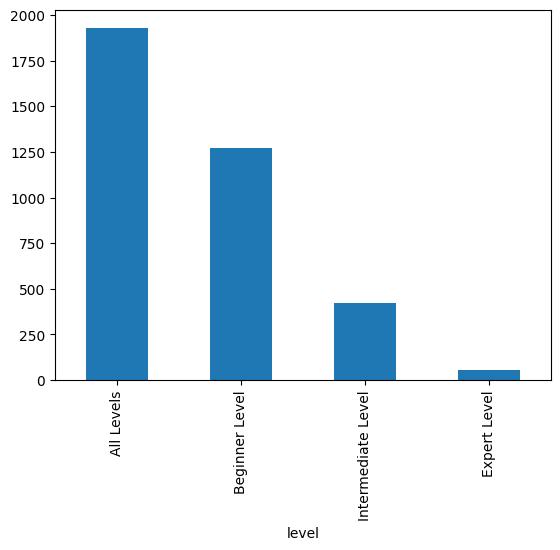

In [38]:
df['level'].value_counts().plot(kind='bar')
plt.show()

### What percentage of the courses in every Level?

In [39]:
fig = px.pie(
    data_frame=df['level'].value_counts(),
    names=df['level'].value_counts().index,  # Use the index (e.g., 'All levels', 'Intermediate Level')
    values=df['level'].value_counts().values, # Use the actual numeric counts
    title='Distribution of Levels',
)
fig.show()

#### 💡 the majorty of Level is 'All Levels'  
#### 💡 the little is 'Expert Level'

## is_paid column

### How many course paid or Free?

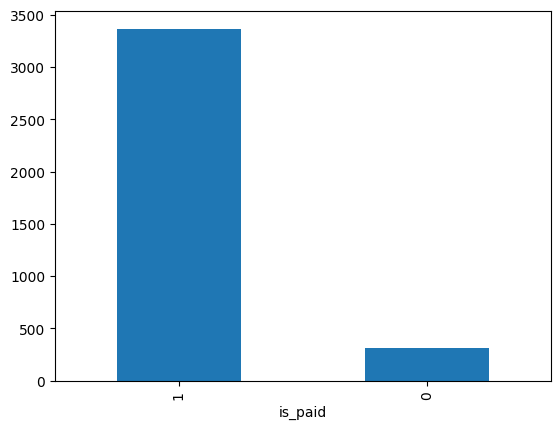

In [40]:
df['is_paid'].value_counts().plot(kind='bar')
plt.show()

### What percentage of the courses Paid or Free?

In [41]:
fig = px.pie(
    data_frame=df['is_paid'].value_counts(),
    names=df['is_paid'].value_counts().index,  # Use the index (e.g., '1' is = True, '0' is =false)
    values=df['is_paid'].value_counts().values, # Use the actual numeric counts
    title='Distribution of is_paid',
)
fig.show()

#### 💡 the majorty of course is 'paid'  
#### 💡 the little of cousre is free 

## subject column

### How many course in every category ?

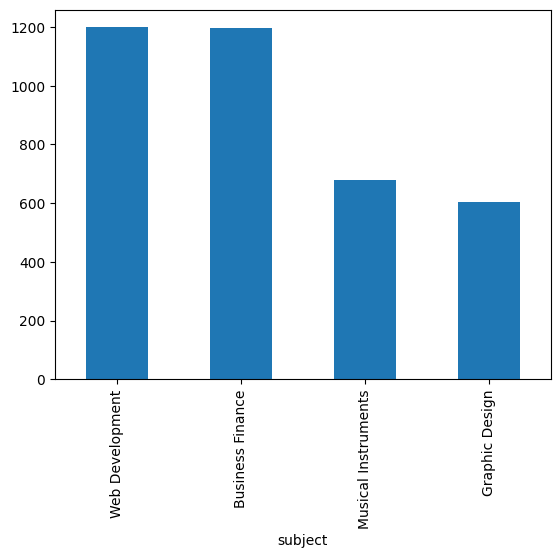

In [42]:
df['subject'].value_counts().plot(kind='bar')
plt.show()

### What percentage of Evey category?

In [43]:
fig = px.pie(
    data_frame=df['subject'].value_counts(),
    names=df['subject'].value_counts().index,  # Use the index (e.g., 'Web Development', 'Business Finance')
    values=df['subject'].value_counts().values, # Use the actual numeric counts
    title='Distribution of subject',
)
fig.show()

#### 💡 the Web & Business are the most popular subjects they control of 65 %
#### 💡 the Musical & Graphic they control of 35 %

## category_duration column

### How many course in every category duration ?

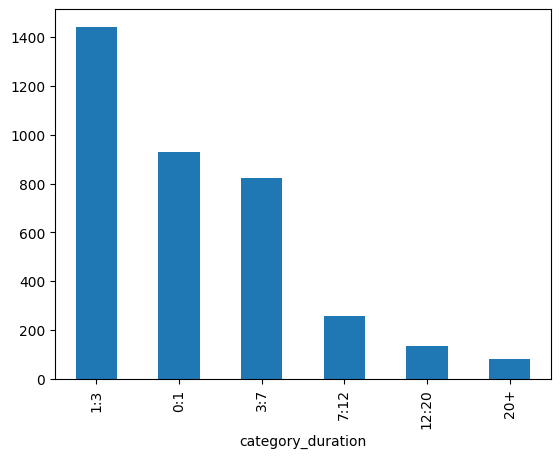

In [44]:
df['category_duration'].value_counts().plot(kind='bar')
plt.show()

### What percentage of Evey category duration ?

In [45]:
fig = px.pie(
    data_frame=df['category_duration'].value_counts(),
    names=df['category_duration'].value_counts().index,  # Use the index (e.g., '1:3', '3:7')
    values=df['category_duration'].value_counts().values, # Use the actual numeric counts
    title='Distribution of category_duration',
)
fig.show()

#### 💡 the Quarter of courses less than 1 hour 25.3%
#### 💡 the majorty of courses are less than 3 hour 39.3%
#### 💡 After them comes courses between 3 to 7 hour
#### 💡 Long courses (more than 7 hours) are rare, making up less than 13% of the total.

## category_price column

### How many course in every category price ?

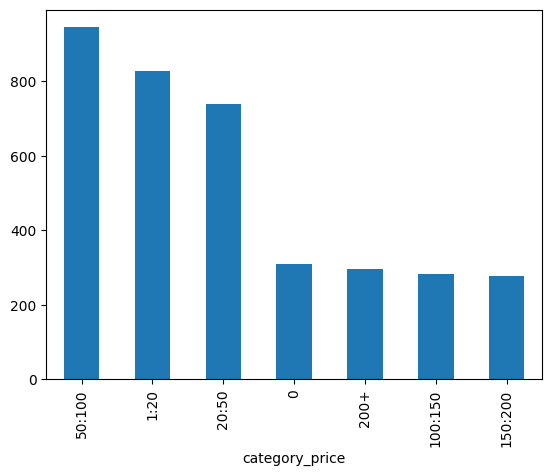

In [46]:
df['category_price'].value_counts().plot(kind='bar')
plt.show()

### What percentage of Evey category price?

In [47]:
fig = px.pie(
    data_frame=df['category_price'].value_counts(),
    names=df['category_price'].value_counts().index,  # Use the index (e.g., '0', '1:20')
    values=df['category_price'].value_counts().values, # Use the actual numeric counts
    title='Distribution of category_price',
)
fig.show()

#### 💡 Free courses (0 price) are very rare, making up only 8.43% of the total.
#### 💡 Highly expensive courses are also uncommon, with the highest ranges (100:150, 150:200, and 200+) each making up around 7% to 8%.
#### 💡 The majority of courses are lower-priced, as the most affordable categories (1:20, 20:50, and 50:100) capture over 68% of the entire chart.

## period column

### How many courses publishind in AM and PM

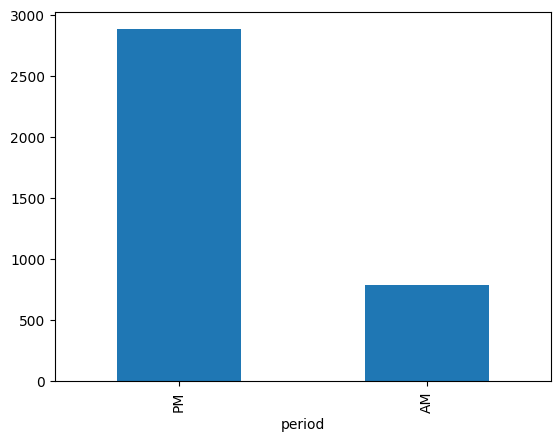

In [48]:
df['period'].value_counts().plot(kind='bar')
plt.show()

### What percentage of the courses are published in AM and PM

In [49]:
fig = px.pie(
    data_frame=df['period'].value_counts(),
    names=df['period'].value_counts().index,  # Use the index (e.g., 'PM', 'AM')
    values=df['period'].value_counts().values, # Use the actual numeric counts
    title='Distribution of period',
)
fig.show()

#### 💡 The vast majority of courses are published in the afternoon or evening (PM), accounting for 78.5% of the total.
#### 💡 Publishing courses in the morning (AM) is much less common, making up only 21.5% of the dataset.

## 2] Bi-variate Analysis

## relation between subject and num_subscribers

### How many subscribers in each subject?

In [50]:
df.groupby('subject')['num_subscribers'].sum()

subject
Business Finance       1870747
Graphic Design         1063148
Musical Instruments     846689
Web Development        7937287
Name: num_subscribers, dtype: int64

In [51]:
fig=px.bar(
    data_frame=df.groupby('subject')['num_subscribers'].sum(),
    x=df.groupby('subject')['num_subscribers'].sum().index,
    y=df.groupby('subject')['num_subscribers'].sum().values,
    text_auto='.4s',
    title='How many subscribers in each subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='num_subscribers')

fig.show()

## relation between subject and profit

### What is the total profit made by each subject?

In [52]:
df.groupby('subject')['profit'].sum()

subject
Business Finance       123796395
Graphic Design          76983170
Musical Instruments     53359055
Web Development        627597400
Name: profit, dtype: int64

In [53]:
fig=px.bar(
    data_frame=df.groupby('subject')['profit'].sum(),
    x=df.groupby('subject')['profit'].sum().index,
    y=df.groupby('subject')['profit'].sum().values,
    text_auto='.4s',
    title='total profit in each subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='profit')

fig.show()

## relation between subject and is_paid

### In each subject, how many paid/unpaid courses?

## Paid

In [54]:
df[df['is_paid']==1]['subject'].value_counts().reset_index()

,subject,count
0,Business Finance,1099
1,Web Development,1066
2,Musical Instruments,634
3,Graphic Design,567


In [55]:
fig=px.bar(
    data_frame=df[df['is_paid']==1]['subject'].value_counts().reset_index(),
    x='subject',
    y='count',
    text_auto='.3s',
    title='total Paid Course in each subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='paid')

fig.show()

## Free

In [56]:
df[df['is_paid']==0]['subject'].value_counts().reset_index()

,subject,count
0,Web Development,133
1,Business Finance,96
2,Musical Instruments,46
3,Graphic Design,35


In [57]:
fig=px.bar(
    data_frame=df[df['is_paid']==0]['subject'].value_counts().reset_index(),
    x='subject',
    y='count',
    text_auto='.3s',
    title='total Free Course in each subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Free')

fig.show()

## relation between category_duration and num_lectures

## Average of number of lectures in each category duration

In [58]:
df.groupby('category_duration',observed=False)['num_lectures'].mean().reset_index()

,category_duration,num_lectures
0,0:1,13.794624
1,1:3,25.653259
2,3:7,48.765492
3,7:12,81.178295
4,12:20,115.444444
5,20+,251.939759


In [59]:
fig=px.bar(
    data_frame=df.groupby('category_duration',observed=False)['num_lectures'].mean().reset_index(),
    x='category_duration',
    y='num_lectures',
    text_auto='.2s',
    title='Average of number of lectures in each category duration'
)
fig.update_xaxes(title='category_duration')
fig.update_yaxes(title='num_lectures')

fig.show()

## relation between category_price and num_subscribers

### How many number of subscribers in each category price

In [60]:
df.groupby('category_price',observed=False)['num_subscribers'].sum().reset_index()

,category_price,num_subscribers
0,0,3575525
1,1:20,1320658
2,20:50,875139
3,50:100,1915595
4,100:150,906814
5,150:200,1787809
6,200+,1336331


In [61]:
fig=px.bar(
    data_frame=df.groupby('category_price',observed=False)['num_subscribers'].sum().reset_index(),
    x='category_price',
    y='num_subscribers',
    text_auto='.2s',
    title='Total of number of subscribers in each category price'
)
fig.update_xaxes(title='category_price')
fig.update_yaxes(title='number of subscribers')

fig.show()

## relation between level and price

### What is the Average price in each level

In [62]:
df.groupby('level')['price'].mean().reset_index()

,level,price
0,All Levels,73.023859
1,Beginner Level,55.717100
2,Expert Level,91.120690
3,Intermediate Level,61.923990


In [63]:
fig=px.bar(
    data_frame=df.groupby('level')['price'].mean().reset_index(),
    x='level',
    y='price',
    text_auto='.2s',
    title='Average of price in each level'
)
fig.update_xaxes(title='level')
fig.update_yaxes(title='Average of price')

fig.show()

## relation between is_paid and num_subscribers

### How many number of subscribers in paid & free

In [64]:
df.groupby('is_paid')['num_subscribers'].sum().reset_index()

,is_paid,num_subscribers
0,0,3575525
1,1,8142346


In [65]:
fig=px.bar(
    data_frame=df.groupby('is_paid')['num_subscribers'].sum().reset_index(),
    x='is_paid',
    y='num_subscribers',
    text_auto='.2s',
    title='Total number of subscribers in paid & free'
)
fig.update_xaxes(title='is_paid')
fig.update_yaxes(title='Total number of subscribers')

fig.show()

## 3] Multi-variate Analysis

## relation between Three Columns [subject ,is_paid,number of course]

### How many courses in each subject, regarding paid / unpaid?

In [66]:
df.groupby(['subject', 'is_paid']).size().reset_index(name='num_courses')

,subject,is_paid,num_courses
0,Business Finance,0,96
1,Business Finance,1,1099
2,Graphic Design,0,35
3,Graphic Design,1,567
4,Musical Instruments,0,46
5,Musical Instruments,1,634
6,Web Development,0,133
7,Web Development,1,1066


In [67]:
fig=px.bar(
    data_frame=df.groupby(['subject', 'is_paid']).size().reset_index(name='num_courses'),
    x='subject',
    y='num_courses',
    color='is_paid',
    text_auto='.2s',
    title='Total Course paid and free in each Subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Number of Courses')

fig.show()

## relation between Three Columns [subject ,is_paid,number of course]

### How many courses in each subject, regarding level ?

In [68]:
df.groupby(['subject', 'level']).size().reset_index(name='num_courses_level')

,subject,level,num_courses_level
0,Business Finance,All Levels,696
1,Business Finance,Beginner Level,340
2,Business Finance,Expert Level,31
3,Business Finance,Intermediate Level,128
4,Graphic Design,All Levels,298
5,Graphic Design,Beginner Level,242
6,Graphic Design,Expert Level,5
7,Graphic Design,Intermediate Level,57
8,Musical Instruments,All Levels,276
9,Musical Instruments,Beginner Level,296


In [69]:
fig=px.bar(
    data_frame=df.groupby(['subject', 'level']).size().reset_index(name='num_courses_level'),
    x='subject',
    y='num_courses_level',
    color='level',
    text_auto='.2s',
    title='Total Level Course in each Subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Number of Courses')

fig.show()

## relation between Three Columns [subject ,category_price,number of course categoryprice]

### How many courses in each subject, regarding category_price ?

In [70]:
df.groupby(['subject', 'category_price'],observed=False).size().reset_index(name='numcourses_categoryprice')

,subject,category_price,numcourses_categoryprice
0,Business Finance,0,96
1,Business Finance,1:20,297
2,Business Finance,20:50,207
3,Business Finance,50:100,302
4,Business Finance,100:150,76
5,Business Finance,150:200,89
6,Business Finance,200+,128
7,Graphic Design,0,35
8,Graphic Design,1:20,202
9,Graphic Design,20:50,140


In [71]:
fig=px.bar(
    data_frame=df.groupby(['subject', 'category_price'],observed=False).size().reset_index(name='numcourses_categoryprice'),
    x='subject',
    y='numcourses_categoryprice',
    color='category_price',
    text_auto='.2s',
    title='Total Number of Courses category price in each Subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Number of Courses')

fig.show()

## relation between Three Columns [subject ,category_duration,number of course category_duration]

### How many courses in each subject, regarding category_duration ?

In [72]:
df.groupby(['subject', 'category_duration'],observed=False).size().reset_index(name='numcourses_categoryduration')

,subject,category_duration,numcourses_categoryduration
0,Business Finance,0:1,324
1,Business Finance,1:3,514
2,Business Finance,3:7,249
3,Business Finance,7:12,57
4,Business Finance,12:20,23
5,Business Finance,20+,23
6,Graphic Design,0:1,200
7,Graphic Design,1:3,215
8,Graphic Design,3:7,115
9,Graphic Design,7:12,49


In [73]:
fig=px.bar(
    data_frame=df.groupby(['subject', 'category_duration'],observed=False).size().reset_index(name='numcourses_categoryduration'),
    x='subject',
    y='numcourses_categoryduration',
    color='category_duration',
    text_auto='.2s',
    title='Total Number of Courses category duration in each Subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Number of Courses')
fig.show()

## relation between Three Columns [subject ,year,number of total_profit]

### How many total_profit in each subject, regarding year ?

In [74]:
df.groupby(['subject', 'year'],observed=False)['profit'].sum().reset_index(name='total_profit')

,subject,year,total_profit
0,Business Finance,2012,190740
1,Business Finance,2013,7298950
2,Business Finance,2014,35870820
3,Business Finance,2015,38702015
4,Business Finance,2016,30727750
5,Business Finance,2017,11006120
6,Graphic Design,2012,1329850
7,Graphic Design,2013,3085300
8,Graphic Design,2014,8364490
9,Graphic Design,2015,23273795


In [75]:
fig=px.bar(
    data_frame=df.groupby(['subject', 'year'],observed=False)['profit'].sum().reset_index(name='total_profit'),
    x='subject',
    y='total_profit',
    color='year',
    text_auto='.2s',
    title='Total profit in each year in each Subject',
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Total profit')

fig.show()

In [76]:
fig=px.line(
    data_frame=df.groupby(['subject', 'year'],observed=False)['profit'].sum().reset_index(name='total_profit'),
    x='year',
    y='total_profit',
    color='subject',
    title='Total profit in each year in each Subject'
)
fig.update_xaxes(title='subject')
fig.update_yaxes(title='Total profit')

fig.show()

In [77]:
df.resample('YE')['profit'].mean().reset_index()

,published_timestamp,profit
0,2011-12-31 00:00:00+00:00,2.328684e+06
1,2012-12-31 00:00:00+00:00,2.616327e+05
2,2013-12-31 00:00:00+00:00,3.453026e+05
3,2014-12-31 00:00:00+00:00,2.182429e+05
4,2015-12-31 00:00:00+00:00,3.101680e+05
5,2016-12-31 00:00:00+00:00,2.297618e+05
6,2017-12-31 00:00:00+00:00,1.266816e+05


In [78]:
fig=px.bar(
    data_frame=df.resample('YE')['profit'].mean().reset_index(),
    x='published_timestamp',
    y='profit',
    text_auto='.2s',
    title='Total profit in each year',
)
fig.update_xaxes(title='year')
fig.update_yaxes(title='profit')

fig.show()

## Save Data To Make ML Model

In [79]:
df.to_csv("EDA Udemy.csv")